# C07 — Non-Cartesian Parallel Imaging & Iterative Reconstruction

**Module 4 · Day 27 · CMRI Lecture 7 (Parallel Imaging III)**

> *Real MRI rarely samples k-space on a tidy grid. Radial and spiral trajectories
> sample it on arbitrary paths — which breaks the clean image-domain unfolding
> that Cartesian SENSE relied on. The fix is to stop thinking "undo the aliasing"
> and start thinking "solve a linear system." This notebook builds that idea from
> the encoding operator up to CG-SENSE.*

This notebook accompanies `C07_summary.md`. Work top to bottom: read, run each
cell, then do the **Exercises** (answers are provided in collapsed-looking
markdown right after each one — try first, then check).

### What you'll build
1. Radial & spiral sampling and their *different aliasing structure*.
2. The non-Cartesian SENSE **encoding operator** `K = F_Ω · C` and its adjoint `Kᴴ`.
3. **Gradient descent** reconstruction (with the analytical gradient you'll derive).
4. **CG-SENSE** (conjugate gradient on the normal equations) — the Pruessmann 2001 method.
5. A convergence comparison (GD vs CG) and a look at **noise propagation**.
6. An optional run on **real radial brain data** (ISMRM RRSG challenge).

These map directly onto the lab tasks in the lecture (slide 41 / the
*data_radial_brain_4ch.mat* exercise).


## 0 · Setup

We use [`sigpy`](https://sigpy.readthedocs.io) for the NUFFT (non-uniform FFT),
which is the standard tool for moving between an image and k-space samples on an
*arbitrary* trajectory. Everything else is `numpy` / `matplotlib`.

If `sigpy` isn't installed: `pip install sigpy`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sigpy as sp
import sigpy.mri as mr

np.random.seed(0)
%matplotlib inline
plt.rcParams["image.cmap"] = "gray"

N = 128          # image side length (bump to 256 once everything runs)
print("sigpy", sp.__version__, "| image size", N)

sigpy 0.1.27 | image size 128


### Helper functions

These four functions ARE the encoding operator. Read them — the rest of the
notebook just calls them.

| function | math | meaning |
|---|---|---|
| `forward(u)`  | $\vec g = K\vec u = \mathcal F_\Omega C\,\vec u$ | image → multi-coil non-Cartesian k-space |
| `adjoint(g)`  | $K^{H}\vec g = \sum_l c_l^{*}\odot \mathcal F^{H}(g_l)$ | k-space → image (the "transpose") |
| `normal_op(u)`| $K^{H}WK\,\vec u$ | one application of the system matrix |
| `nrmse(x,ref)`| — | scale-invariant error metric for monitoring |

`dcf` is the **density compensation function**: radial/spiral sample the centre of
k-space far more densely than the edges, so the adjoint over-weights low
frequencies. Multiplying by `dcf` (a ramp ~ $|k_r|$ for radial) corrects this and
makes the adjoint a decent *gridding* reconstruction on its own.

In [2]:
def make_phantom(N):
    return sp.shepp_logan((N, N)).astype(np.complex64)

def make_sensitivities(N, ncoils, r=1.5):
    # smooth complex birdcage-style maps, normalised to sum-of-squares = 1
    C = mr.birdcage_maps((ncoils, N, N), r=r).astype(np.complex64)
    rss = np.sqrt((np.abs(C)**2).sum(0, keepdims=True))
    return (C / np.where(rss == 0, 1, rss)).astype(np.complex64)

def radial_traj(N, nspokes, nread):
    ang = np.pi * np.arange(nspokes) / nspokes          # 0..pi
    rho = np.linspace(-0.5, 0.5, nread)
    kx = np.outer(np.cos(ang), rho); ky = np.outer(np.sin(ang), rho)
    return (np.stack([kx, ky], -1) * N).astype(np.float32)   # sigpy units = samples

def radial_dcf(nspokes, nread):
    rho = np.abs(np.linspace(-0.5, 0.5, nread))         # ramp filter ~ |k_r|
    d = np.tile(rho, (nspokes, 1)).astype(np.float32)
    return d / d.max()

def spiral_traj(N, ninterleaves, nturns=10, nsamp=2048):
    t = np.linspace(0, 1, nsamp)
    rho = 0.5 * t                                       # grows to k-max
    out = []
    for i in range(ninterleaves):
        phi = 2*np.pi*nturns*t + 2*np.pi*i/ninterleaves
        out.append(np.stack([rho*np.cos(phi), rho*np.sin(phi)], -1))
    return (np.stack(out, 0) * N).astype(np.float32)    # (ninterleaves, nsamp, 2)

def forward(u, C, coord):
    return np.stack([sp.nufft(C[c]*u, coord) for c in range(C.shape[0])], 0)

def adjoint(g, C, coord, oshape, dcf=None):
    acc = np.zeros(oshape, np.complex64)
    for c in range(C.shape[0]):
        gc = g[c]*dcf if dcf is not None else g[c]
        acc += np.conj(C[c]) * sp.nufft_adjoint(gc, coord, oshape=oshape)
    return acc

def normal_op(u, C, coord, dcf=None):
    return adjoint(forward(u, C, coord), C, coord, u.shape, dcf=dcf)

def nrmse(x, ref):
    x, ref = np.abs(x), np.abs(ref)
    s = np.vdot(x, ref) / np.vdot(x, x)                 # best least-squares scaling
    return float(np.linalg.norm(s*x - ref) / np.linalg.norm(ref))

print("helpers ready")

helpers ready


## 1 · Non-Cartesian sampling and its *different aliasing structure*

The single most important visual idea in this lecture: **how you undersample
determines what the aliasing looks like.**

- **Cartesian** undersampling (skip every other line) → clean, coherent *fold-over*
  (a sharp copy of the anatomy shifted by FOV/2). This is what classic SENSE undoes.
- **Radial** undersampling → incoherent *streaks*.
- **Spiral** undersampling → swirly, structured blur where "the value of pixels &
  intensity is not obvious" (as the lecturer's annotation puts it).

Let's reproduce all three on one phantom.

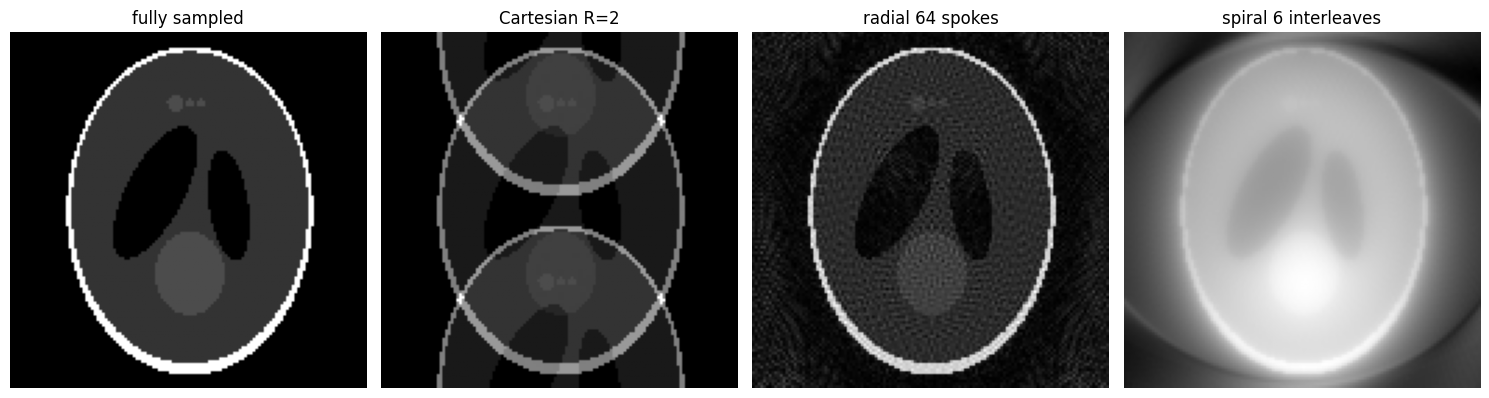

In [3]:
img = make_phantom(N)
C1  = make_sensitivities(N, 1)              # single coil: just look at aliasing

# Cartesian R=2: keep every other phase-encode line
ksp_full = sp.fft(img)
mask = np.zeros((N, N), bool); mask[::2] = True
cart_r2 = sp.ifft(ksp_full*mask)

# Radial, 64 spokes (R ~ pi/2 * N/nspokes for full radial)
rc = radial_traj(N, 64, 2*N); rdcf = radial_dcf(64, 2*N)
g_rad  = forward(img, C1, rc)
rad    = adjoint(g_rad, C1, rc, (N, N), dcf=rdcf)

# Spiral, 6 interleaves
sc = spiral_traj(N, 6)
g_sp = np.stack([sp.nufft(img, sc)], 0)     # single coil
sp_im = sp.nufft_adjoint(g_sp[0], sc, oshape=(N, N))

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, (im, t) in zip(ax, [(img,"fully sampled"),(cart_r2,"Cartesian R=2"),
                            (rad,"radial 64 spokes"),(sp_im,"spiral 6 interleaves")]):
    a.imshow(np.abs(im)); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

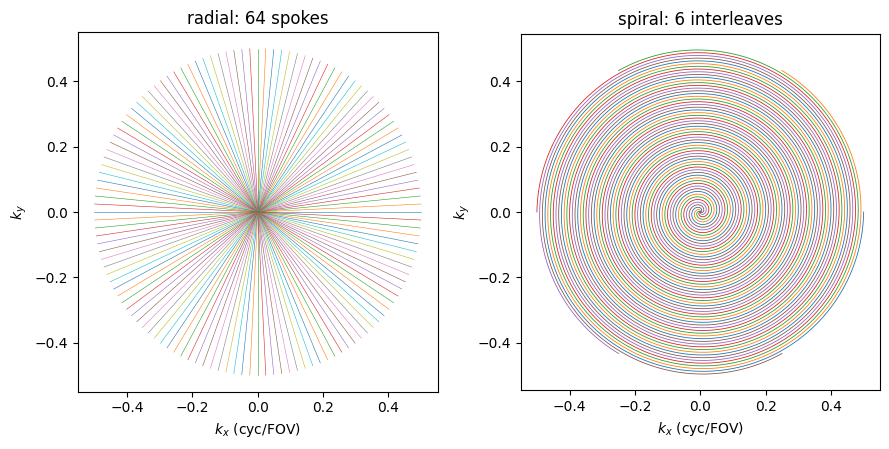

In [4]:
# The trajectories themselves
fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
for s in range(0, 64, 1):
    ax[0].plot(rc[s,:,0]/N, rc[s,:,1]/N, lw=.4)
ax[0].set_title("radial: 64 spokes"); ax[0].set_aspect("equal")
for i in range(6):
    ax[1].plot(sc[i,:,0]/N, sc[i,:,1]/N, lw=.6)
ax[1].set_title("spiral: 6 interleaves"); ax[1].set_aspect("equal")
for a in ax: a.set_xlabel("$k_x$ (cyc/FOV)"); a.set_ylabel("$k_y$")
plt.tight_layout(); plt.show()

**Why this matters for parallel imaging.** Cartesian SENSE works by unfolding a
*small, known* set of superimposed pixels per location — its point-spread function
is a handful of sharp, equidistant peaks. Radial/spiral PSFs are continuous,
ring-shaped structures, so there is no neat per-pixel unfolding. We need a method
that doesn't care about the PSF shape: pose reconstruction as a **linear inverse
problem** and solve it iteratively.

## 2 · The encoding operator and why we can't just invert it

The multi-coil signal model, discretised (lecture slides 11–12):

$$g_k(k_x,k_y)=\sum_{x}\sum_{y}\underbrace{c_k(x,y)}_{\text{coil sens.}}\;
e^{-i(k_x x + k_y y)}\;\underbrace{u(x,y)}_{\text{image}}
\quad\Longrightarrow\quad \vec g = \mathcal F_\Omega\,C\,\vec u = K\vec u$$

So reconstruction is "just" solving the linear system $K\vec u = \vec g$. The direct
solution is the pseudoinverse $\vec u = (K^{H}K)^{-1}K^{H}\vec g$ — but $K$ is enormous:

> N=256, 8 coils, 256 spokes × 256 samples → **K is 528,384 × 65,536 ≈ 139 GB.**

You cannot form, let alone invert, that matrix. The escape hatch: never build $K$.
We only ever need to *apply* $K$ and $K^{H}$ (each is a few NUFFTs + pointwise
multiplies), and iterative solvers need nothing more.

In [5]:
# Sanity check the adjoint really is the adjoint: <K u, g> == <u, K^H g>
ncoils = 4
C = make_sensitivities(N, ncoils)
u_test = (np.random.randn(N,N)+1j*np.random.randn(N,N)).astype(np.complex64)
g_test = (np.random.randn(ncoils,64,2*N)+1j*np.random.randn(ncoils,64,2*N)).astype(np.complex64)
lhs = np.vdot(forward(u_test, C, rc), g_test)
rhs = np.vdot(u_test, adjoint(g_test, C, rc, (N,N)))
print(f"<Ku,g> = {lhs:.3e}")
print(f"<u,K^H g> = {rhs:.3e}")
print("adjoint test relative error:", abs(lhs-rhs)/abs(lhs))

<Ku,g> = -7.791e+01+1.820e+00j
<u,K^H g> = -7.791e+01+1.820e+00j
adjoint test relative error: 8.593578e-06


## 3 · Exercise 1 — derive the gradient (analytical)

In gradient descent we minimise the data-consistency cost
$f(\vec u)=\lVert K\vec u-\vec g\rVert_2^2$. The lecture states (slide 21) that

$$\frac{\partial}{\partial \vec u}\,\lVert K\vec u-\vec g\rVert_2^2 = 2K^{T}(K\vec u-\vec g).$$

**Your task:** prove this. Assume real-valued $K,\vec u,\vec g$ and feel free to use a
$2\times2$ example to keep the bookkeeping light. *Hints:* write the squared norm as
an inner product $(K\vec u-\vec g)^{T}(K\vec u-\vec g)$, and use
$\vec b^{T}A\vec x=(\vec b^{T}A\vec x)^{T}$.

<details><summary><b>Answer (try first!)</b></summary>

Let $\vec r = K\vec u-\vec g$ and $f=\lVert\vec r\rVert_2^2=\sum_i r_i^2$.

Write $f$ via the chain rule with $u_i=(K\vec u-\vec g)_i$ and $y=\sum_i u_i^2$:

$$\frac{dy}{d u_i}=2u_i,\qquad
\frac{\partial f}{\partial \vec u}=\sum_i 2u_i\,\frac{\partial u_i}{\partial\vec u}
=\sum_i 2u_i\,K_i^{T}=2K^{T}(K\vec u-\vec g).$$

Equivalently, expand directly:
$$f=(K\vec u-\vec g)^{T}(K\vec u-\vec g)
=\vec u^{T}K^{T}K\vec u-2\vec g^{T}K\vec u+\vec g^{T}\vec g,$$
using $\vec g^{T}K\vec u=(\vec g^{T}K\vec u)^{T}=\vec u^{T}K^{T}\vec g$ (a scalar equals
its transpose). Differentiating the quadratic form
$\partial_{\vec u}(\vec u^{T}B\vec u)=2B\vec u$ with $B=K^{T}K$ symmetric, and the
linear term, gives

$$\nabla f = 2K^{T}K\vec u - 2K^{T}\vec g = 2K^{T}(K\vec u-\vec g).\qquad\blacksquare$$

(For complex data the result is the same with $K^{T}\!\to K^{H}$, which is exactly
what `adjoint()` implements; the full complex Wirtinger derivation is a bit more
involved, hence the real-valued assumption here.)
</details>

## 4 · Exercise 2 — gradient descent reconstruction

Now implement the update rule from slide 16:

$$\vec u_{n+1}=\vec u_n-t\,\big(2K^{T}(K\vec u_n-\vec g)\big),\qquad \vec u_0=\vec 0.$$

We fold the constant 2 into the step size. The only subtlety vs. the lab's fixed
`t=1e-2` is the **step size**: too small → underfit/blurry; too large → diverges
(the lab's `t=0.1` "blows up", exactly as their Table 1 shows). A safe automatic
choice is $t\le 1/L$ where $L$ is the largest eigenvalue of $K^{H}K$, found by a
few power iterations.

In [6]:
def grad_descent(g, C, coord, niter=100, step=None, dcf=None, ref=None):
    KHg = adjoint(g, C, coord, (N, N), dcf=dcf)
    u = np.zeros((N, N), np.complex64)
    if step is None:                               # power iteration -> Lipschitz const
        b = (np.random.randn(N, N)+1j*np.random.randn(N, N)).astype(np.complex64)
        for _ in range(10):
            b = normal_op(b, C, coord, dcf=dcf); b /= np.linalg.norm(b)
        L = np.linalg.norm(normal_op(b, C, coord, dcf=dcf))
        step = 1.0 / L
    errs = []
    for it in range(niter):
        grad = normal_op(u, C, coord, dcf=dcf) - KHg     # = (1/2) full gradient
        u = u - step * grad
        if ref is not None: errs.append(nrmse(u, ref))
    return u, errs, step

# build a realistic 4-coil, 64-spoke radial dataset
C = make_sensitivities(N, 4)
coord, dcf = rc, rdcf
g = forward(img, C, coord)

u_grid = adjoint(g, C, coord, (N, N), dcf=dcf)
u_gd, errs_gd, step = grad_descent(g, C, coord, niter=100, dcf=dcf, ref=img)
print(f"auto step size t = {step:.3f}")
print(f"gridding NRMSE = {nrmse(u_grid, img):.3f}  |  GD(100) NRMSE = {errs_gd[-1]:.3f}")

auto step size t = 0.439
gridding NRMSE = 0.246  |  GD(100) NRMSE = 0.115


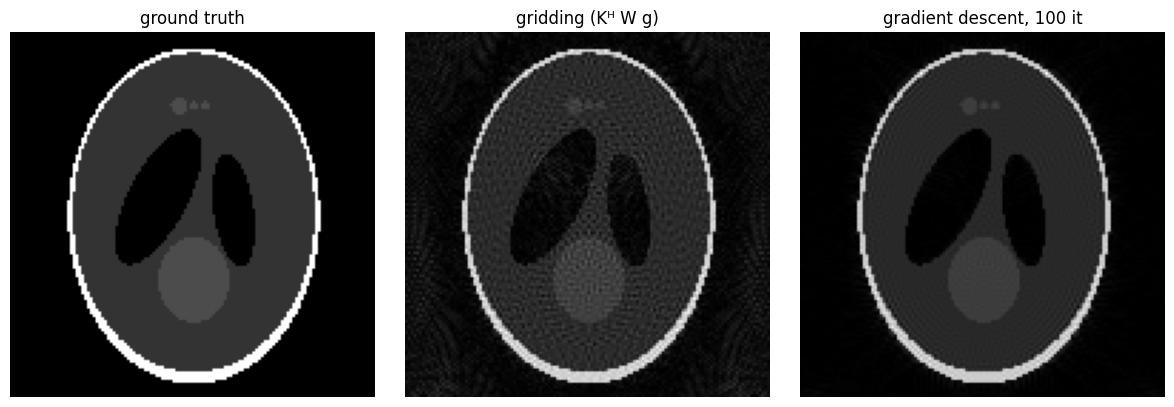

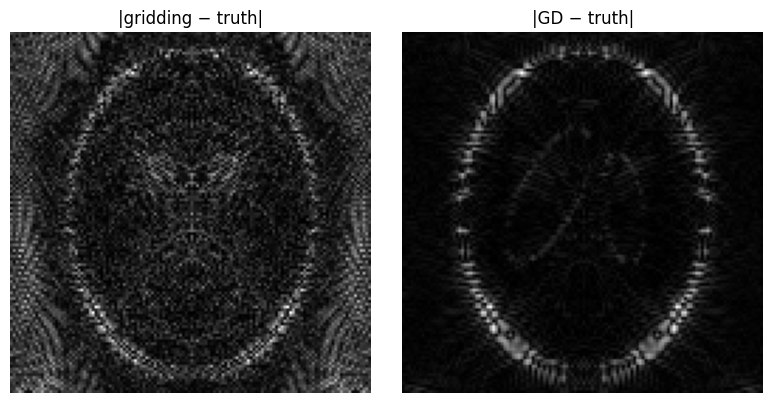

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, (im, t) in zip(ax, [(img,"ground truth"),
                           (u_grid,"gridding (Kᴴ W g)"),
                           (u_gd,"gradient descent, 100 it")]):
    a.imshow(np.abs(im)); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

# difference images (lab task 2.5.2)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
sg = np.vdot(np.abs(u_grid),np.abs(img))/np.vdot(np.abs(u_grid),np.abs(u_grid))
sd = np.vdot(np.abs(u_gd),  np.abs(img))/np.vdot(np.abs(u_gd),  np.abs(u_gd))
ax[0].imshow(np.abs(sg*np.abs(u_grid)-np.abs(img))); ax[0].set_title("|gridding − truth|"); ax[0].axis("off")
ax[1].imshow(np.abs(sd*np.abs(u_gd)  -np.abs(img))); ax[1].set_title("|GD − truth|");       ax[1].axis("off")
plt.tight_layout(); plt.show()

Notice the structure of the two error maps — this is lab task 2.5.2. Gridding
error is **streaky** (residual radial aliasing); GD error is **smooth/blurry**
(it has suppressed the incoherent streaks but hasn't yet recovered fine high-
frequency detail). That trade-off is the whole story of iterative recon.

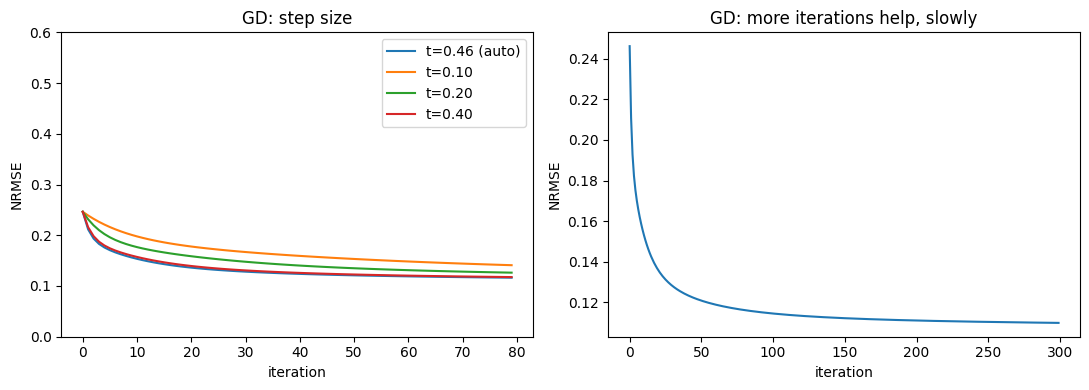

GD keeps improving but with strongly diminishing returns — motivation for CG.


In [8]:
# Hyperparameter sweep (lab task 2.7): step size & iteration count
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for t in [None, 0.1, 0.2, 0.4]:
    _, e, used = grad_descent(g, C, coord, niter=80, step=t, dcf=dcf, ref=img)
    ax[0].plot(e, label=f"t={used:.2f}" + (" (auto)" if t is None else ""))
ax[0].set(title="GD: step size", xlabel="iteration", ylabel="NRMSE"); ax[0].legend()
ax[0].set_ylim(0, 0.6)

_, e_full, _ = grad_descent(g, C, coord, niter=300, dcf=dcf, ref=img)
ax[1].plot(e_full); ax[1].set(title="GD: more iterations help, slowly",
                              xlabel="iteration", ylabel="NRMSE")
plt.tight_layout(); plt.show()
print("GD keeps improving but with strongly diminishing returns — motivation for CG.")

## 5 · CG-SENSE — conjugate gradient on the normal equations

Gradient descent's flaw: successive steepest-descent directions are orthogonal, so
it zig-zags across narrow valleys (lecture slide 15). **Conjugate gradient** instead
uses directions that are *K-orthogonal* (conjugate), $\vec p_k^{T}K\vec p_{k+1}=0$,
and — for an $n\times n$ system — reaches the exact solution in $n$ steps, with the
required tolerance usually hit in **far fewer** ($it \ll n$).

CG requires a symmetric positive-definite matrix, so we apply it to the **normal
equations** (slide 23):

$$K^{H}K\,\vec u = K^{H}\vec g.$$

Here $A=K^{H}WK$ is exactly our `normal_op`, and the right-hand side
$\vec b=K^{H}W\vec g$ is exactly the gridding image. This is the Pruessmann 2001
CG-SENSE algorithm — only ~20 lines.

CG-SENSE(30) NRMSE = 0.109


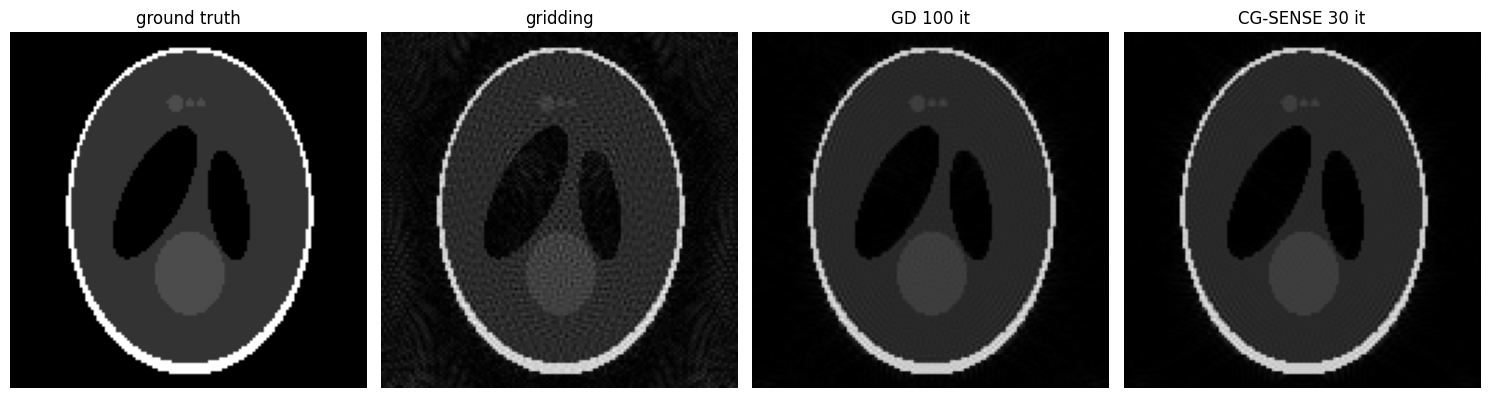

In [9]:
def cg_sense(g, C, coord, niter=30, dcf=None, ref=None, tol=1e-10):
    b = adjoint(g, C, coord, (N, N), dcf=dcf)          # b = K^H W g
    x = np.zeros((N, N), np.complex64)
    r = b - normal_op(x, C, coord, dcf=dcf)            # residual
    p = r.copy()
    rs_old = np.vdot(r, r).real
    errs = []
    for it in range(niter):
        Ap    = normal_op(p, C, coord, dcf=dcf)
        alpha = rs_old / np.vdot(p, Ap).real           # step length
        x     = x + alpha * p                          # update
        r     = r - alpha * Ap                         # new residual
        rs_new = np.vdot(r, r).real
        if ref is not None: errs.append(nrmse(x, ref))
        if rs_new < tol: break
        p      = r + (rs_new / rs_old) * p             # new conjugate direction
        rs_old = rs_new
    return x, errs

u_cg, errs_cg = cg_sense(g, C, coord, niter=30, dcf=dcf, ref=img)
print(f"CG-SENSE(30) NRMSE = {errs_cg[-1]:.3f}")

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, (im, t) in zip(ax, [(img,"ground truth"),(u_grid,"gridding"),
                           (u_gd,"GD 100 it"),(u_cg,"CG-SENSE 30 it")]):
    a.imshow(np.abs(im)); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

## 6 · Convergence: GD vs CG (lab task 3.2)

Same data, same operator — only the solver differs. The lab promises CG converges
"in 20–30 iterations" while GD crawls. Let's see it.

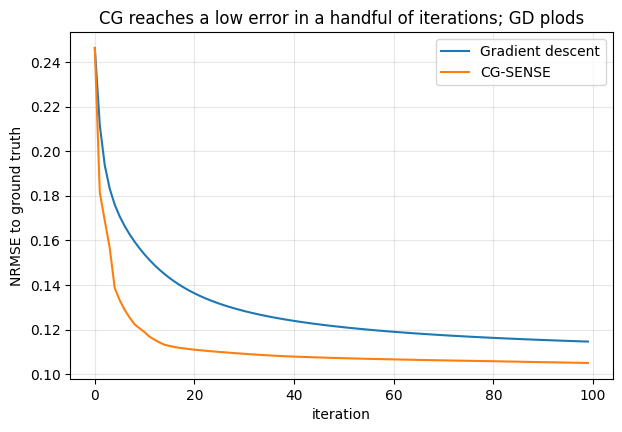

iter   5:  GD=0.176   CG=0.139
iter  10:  GD=0.156   CG=0.121
iter  20:  GD=0.137   CG=0.111
iter  50:  GD=0.121   CG=0.107


In [10]:
_, errs_gd_long, _ = grad_descent(g, C, coord, niter=100, dcf=dcf, ref=img)
_, errs_cg_long     = cg_sense(g, C, coord, niter=100, dcf=dcf, ref=img)

plt.figure(figsize=(7, 4.5))
plt.plot(errs_gd_long, label="Gradient descent")
plt.plot(errs_cg_long, label="CG-SENSE")
plt.xlabel("iteration"); plt.ylabel("NRMSE to ground truth")
plt.title("CG reaches a low error in a handful of iterations; GD plods")
plt.legend(); plt.grid(alpha=.3); plt.show()

for k in [5, 10, 20, 50]:
    print(f"iter {k:>3}:  GD={errs_gd_long[k-1]:.3f}   CG={errs_cg_long[k-1]:.3f}")

### 6b · Noise propagation & Exercise 3 (lab task 3.4)

CG is fast, but as a solver of the *exact* system it is **unstable to perturbations**
(slide 22). Two ways to see this:

1. **Higher acceleration → noisier recon.** Fewer spokes means a more
   ill-conditioned $K^{H}K$, so noise in the data is amplified.
2. **Reconstruct pure noise.** Feed random data instead of real k-space and run
   many iterations. Because CG keeps fitting the (meaningless) data, the result in
   k-space reveals the **sampling trajectory** itself — the algorithm has amplified
   noise along exactly the directions the trajectory constrains. This is the
   "what did you just obtain?" moment in the lab.

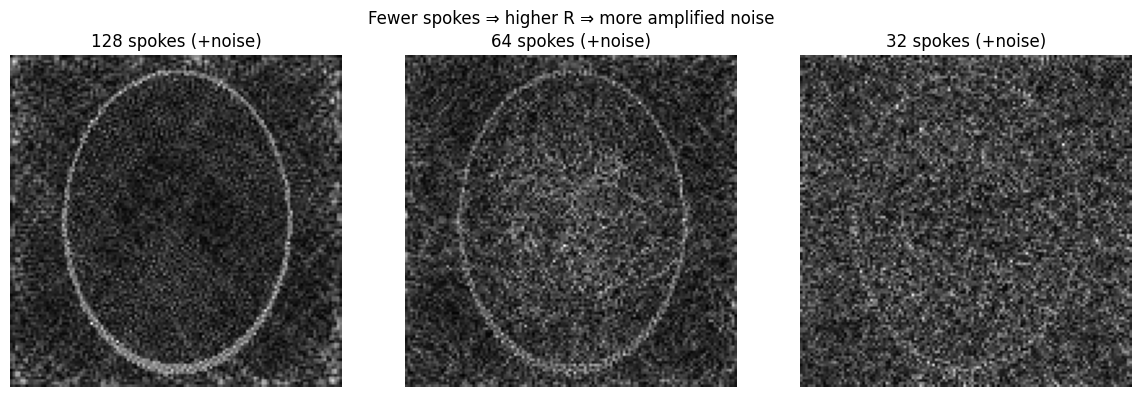

In [11]:
# 1) acceleration vs noise: add measurement noise, vary number of spokes
def recon_at_spokes(nspokes, noise=0.02, niter=30):
    cc = radial_traj(N, nspokes, 2*N); dd = radial_dcf(nspokes, 2*N)
    gg = forward(img, C, cc)
    gg = gg + noise*np.abs(gg).max()*(np.random.randn(*gg.shape)+1j*np.random.randn(*gg.shape))
    x, _ = cg_sense(gg, C, cc, niter=niter, dcf=dd)
    return x

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, ns in zip(ax, [128, 64, 32]):
    a.imshow(np.abs(recon_at_spokes(ns))); a.set_title(f"{ns} spokes (+noise)"); a.axis("off")
plt.suptitle("Fewer spokes ⇒ higher R ⇒ more amplified noise"); plt.tight_layout(); plt.show()

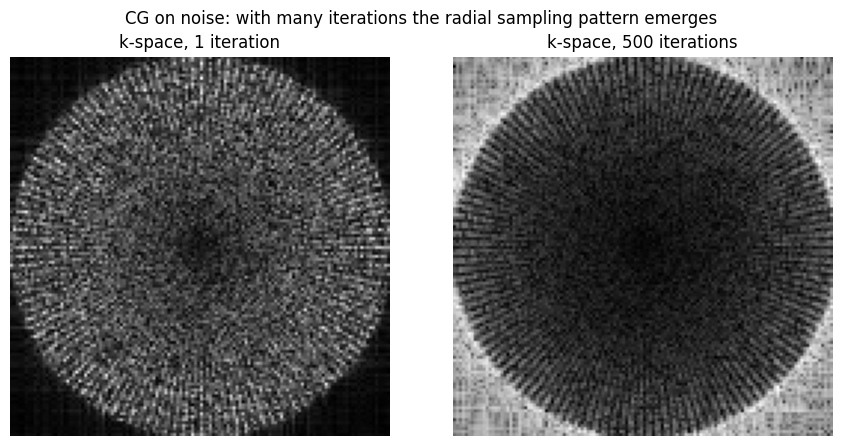

In [12]:
# 2) CG on pure noise (lab 3.4): the trajectory appears in k-space
g_noise = (np.random.randn(*g.shape)+1j*np.random.randn(*g.shape)).astype(np.complex64)
x1,  _ = cg_sense(g_noise, C, coord, niter=1,   dcf=dcf)
x500,_ = cg_sense(g_noise, C, coord, niter=500, dcf=dcf)

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(np.log1p(np.abs(sp.fft(x1))));   ax[0].set_title("k-space, 1 iteration");   ax[0].axis("off")
ax[1].imshow(np.log1p(np.abs(sp.fft(x500)))); ax[1].set_title("k-space, 500 iterations"); ax[1].axis("off")
plt.suptitle("CG on noise: with many iterations the radial sampling pattern emerges")
plt.tight_layout(); plt.show()

**Takeaway (the answer to "what did you just obtain?"):** running CG to convergence
on noise does *not* drive the error down — instead it amplifies noise along the
sampled trajectory, so the k-space of the result lights up exactly where the radial
spokes lie. In practice this is why CG-SENSE is run for only a limited number of
iterations (early stopping acts as regularisation), and why real pipelines add an
explicit regulariser (e.g. Tikhonov / total variation / a learned prior — that's
Module 5).

## 7 · Self-test (answers in `C07_summary.md`)

1. Why can't general (radial/spiral) SENSE be solved by the simple per-pixel
   unfolding used for Cartesian SENSE?
2. For N=256, 8 coils, 256×256 radial samples, the encoding matrix is ~139 GB.
   What property of iterative solvers lets us avoid ever forming it?
3. Write the gradient-descent update for $\min_u\lVert Ku-g\rVert_2^2$ and explain
   what goes wrong if the step size is too large (relate to the lab's `t=0.1` row).
4. What does it mean for two CG search directions to be *conjugate*, and why does
   that beat steepest descent's orthogonal directions?
5. Why is CG applied to the *normal equations* $K^{H}Ku=K^{H}g$ rather than to
   $Ku=g$ directly?
6. CG converges to the exact solution in $n$ steps in theory, yet we stop after
   ~20–30. Give two reasons.
7. You reconstruct pure noise with CG for 500 iterations and look at k-space. What
   appears, and what does it tell you about CG's stability?

### Where this fits
- **Builds on:** C05 (image-space SENSE) and C06 (k-space GRAPPA).
- **Sets up:** Module 5 — once you see recon as $\min_u \lVert Ku-g\rVert^2 + \lambda R(u)$,
  swapping the handcrafted regulariser $R$ for a *learned* one (unrolled networks)
  is the natural next step.
